
# Text Data Assignment — Vietnamese Sentiment Classification

**Dataset:** UIT-VSFC — Vietnamese Students' Feedback Corpus  
**Task:** Classify Vietnamese student feedback into **negative / neutral / positive** sentiment.

## Why this dataset?

- Vietnamese text classification dataset.
- More than 16,000 labeled text samples.
- Three predefined splits: train, validation, and test.
- Three sentiment classes: `negative`, `neutral`, `positive`.
- Suitable for an end-to-end classical machine-learning workflow with Pandas, NumPy, Matplotlib, and Scikit-learn.
- The Hugging Face mirror used in this notebook is labeled **CC BY-NC-SA 4.0**.

**Dataset mirror:** https://huggingface.co/datasets/ura-hcmut/UIT-VSFC  
**Original paper:** K. V. Nguyen et al., *UIT-VSFC: Vietnamese Students’ Feedback Corpus for Sentiment Analysis*, KSE 2018.

## Workflow

1. Load and validate the dataset.
2. Exploratory data analysis (EDA).
3. Normalize Vietnamese text.
4. Establish a majority-class baseline.
5. Compare multiple TF-IDF + classical ML models.
6. Select the best model using validation Macro-F1.
7. Refit on train + validation and evaluate once on the test set.
8. Analyze the confusion matrix and misclassified examples.
9. Interpret useful n-grams from a linear model.
10. Run example predictions.

> The test set is used only after model selection to avoid test-set leakage.


In [1]:

# Colab already includes most of these packages.
# Run this cell if your environment is missing any dependency.
%pip -q install -U pandas numpy matplotlib scikit-learn


Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import re
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
LABEL_ORDER = ["negative", "neutral", "positive"]

pd.set_option("display.max_colwidth", 120)
np.random.seed(RANDOM_STATE)



## 1. Load UIT-VSFC

The notebook reads the public CSV files directly from the Hugging Face dataset mirror. This keeps the notebook simple and makes it runnable on Google Colab without manually uploading data.


In [18]:
BASE_URL = "https://huggingface.co/datasets/ura-hcmut/UIT-VSFC/resolve/main"

DATA_URLS = {
    "train": f"{BASE_URL}/UIT-VSFC_train.csv",
    "validation": f"{BASE_URL}/UIT-VSFC_valid.csv",
    "test": f"{BASE_URL}/UIT-VSFC_test.csv",
}

LABEL_ORDER = ["negative", "neutral", "positive"]


def clean_labels(series):
    """
    Convert all labels to consistent strings and preserve missing values.
    """
    series = series.astype("string")
    series = series.str.strip().str.lower()

    # Normalize possible malformed/missing representations
    series = series.replace({
        "": pd.NA,
        "nan": pd.NA,
        "none": pd.NA,
        "null": pd.NA,
    })

    return series


def load_split(url: str, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(url)

    # Normalize column names
    df.columns = [str(c).strip().lower() for c in df.columns]

    required = {"text", "label"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(
            f"{split_name}: missing required columns: {missing}"
        )

    df = df[["text", "label"]].copy()

    # Clean text
    df["text"] = df["text"].astype("string")

    # Clean labels
    df["label"] = clean_labels(df["label"])

    # Remove rows without text or label
    before = len(df)

    df = df.dropna(
        subset=["text", "label"]
    ).copy()

    df = df[
        df["text"].str.strip().ne("")
    ].copy()

    removed = before - len(df)

    if removed > 0:
        print(
            f"{split_name}: removed {removed} rows "
            "with missing text/label"
        )

    # Verify labels
    invalid_labels = set(df["label"].unique()) - set(LABEL_ORDER)

    if invalid_labels:
        raise ValueError(
            f"{split_name}: unexpected labels found: "
            f"{invalid_labels}"
        )

    # Use ordinary Python strings for sklearn compatibility
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(str)

    df["split"] = split_name

    return df


train_df = load_split(
    DATA_URLS["train"],
    "train"
)

valid_df = load_split(
    DATA_URLS["validation"],
    "validation"
)

test_df = load_split(
    DATA_URLS["test"],
    "test"
)


print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

print()
print("Train label types:")
print(train_df["label"].map(type).value_counts())

print()
print("Validation labels:")
print(valid_df["label"].value_counts())

print()
print("Test labels:")
print(test_df["label"].value_counts())

validation: removed 1 rows with missing text/label
Train: (11426, 3)
Validation: (1583, 3)
Test: (3166, 3)

Train label types:
label
<class 'str'>    11426
Name: count, dtype: int64

Validation labels:
label
positive    805
negative    705
neutral      73
Name: count, dtype: int64

Test labels:
label
positive    1590
negative    1409
neutral      167
Name: count, dtype: int64


In [19]:

# Basic integrity checks
all_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

print("Total samples:", len(all_df))
print("Labels:", sorted(all_df["label"].dropna().unique().tolist()))
print("Missing text:", int(all_df["text"].isna().sum()))
print("Missing label:", int(all_df["label"].isna().sum()))
print("Exact duplicate rows:", int(all_df.duplicated(subset=["text", "label"]).sum()))

unexpected = set(all_df["label"].dropna().unique()) - set(LABEL_ORDER)
assert not unexpected, f"Unexpected labels found: {unexpected}"
assert len(all_df) >= 2000, "Dataset does not satisfy the minimum 2,000-text requirement."


Total samples: 16175
Labels: ['negative', 'neutral', 'positive']
Missing text: 0
Missing label: 0
Exact duplicate rows: 0


## 2. Exploratory Data Analysis

In [20]:

# Split-level summary
split_summary = (
    all_df.groupby("split")
    .agg(
        samples=("text", "size"),
        unique_texts=("text", "nunique"),
    )
    .reindex(["train", "validation", "test"])
)
display(split_summary)

# Label counts and proportions
label_counts = pd.crosstab(all_df["split"], all_df["label"]).reindex(
    index=["train", "validation", "test"],
    columns=LABEL_ORDER,
    fill_value=0,
)
display(label_counts)

label_percent = label_counts.div(label_counts.sum(axis=1), axis=0).mul(100).round(2)
display(label_percent)


,samples,unique_texts
split,,
train,11426,11425
validation,1583,1583
test,3166,3166


label,negative,neutral,positive
split,,,
train,5325,458,5643
validation,705,73,805
test,1409,167,1590


label,negative,neutral,positive
split,,,
train,46.60,4.01,49.39
validation,44.54,4.61,50.85
test,44.50,5.27,50.22


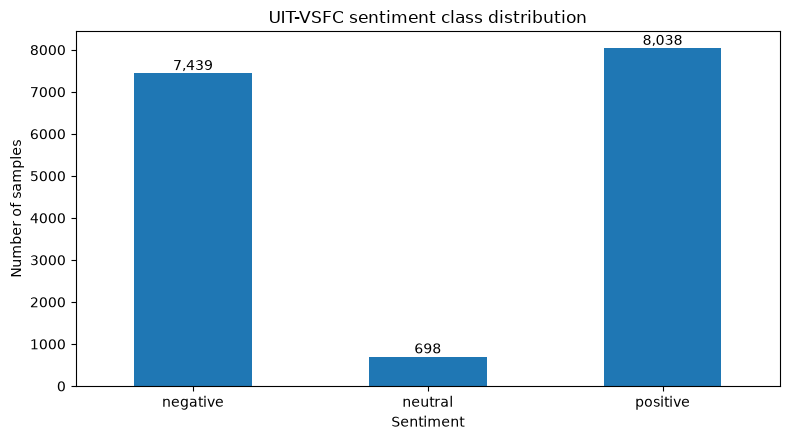

Observation: if one class is much smaller than the others, Macro-F1 is more informative than accuracy alone.


In [21]:

# Sentiment class distribution
overall_counts = all_df["label"].value_counts().reindex(LABEL_ORDER)

fig, ax = plt.subplots(figsize=(8, 4.5))
overall_counts.plot(kind="bar", ax=ax)
ax.set_title("UIT-VSFC sentiment class distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(overall_counts.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(
    "Observation: if one class is much smaller than the others, "
    "Macro-F1 is more informative than accuracy alone."
)


char_len                        word_len                       
            count   mean median min  max    count   mean median min  max
label                                                                   
negative     7439  70.54   56.0   4  718     7439  16.89   13.0   2  161
neutral       698  39.19   30.0   4  334      698   9.82    8.0   2   79
positive     8038  49.57   42.0   5  394     8038  12.15   10.0   2   95

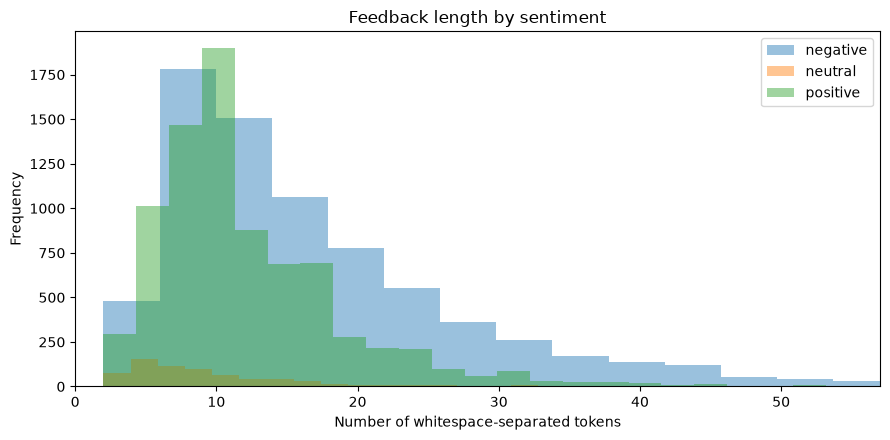

In [22]:

# Text-length statistics
all_df["char_len"] = all_df["text"].fillna("").astype(str).str.len()
all_df["word_len"] = all_df["text"].fillna("").astype(str).str.split().str.len()

display(
    all_df.groupby("label")[["char_len", "word_len"]]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for label in LABEL_ORDER:
    subset = all_df.loc[all_df["label"] == label, "word_len"]
    ax.hist(subset, bins=40, alpha=0.45, label=label)

ax.set_title("Feedback length by sentiment")
ax.set_xlabel("Number of whitespace-separated tokens")
ax.set_ylabel("Frequency")
ax.set_xlim(0, min(120, int(all_df["word_len"].quantile(0.99)) + 5))
ax.legend()
plt.tight_layout()
plt.show()


In [23]:

# Inspect random examples from every class
samples = (
    all_df[["label", "text"]]
    .groupby("label", group_keys=False)
    .sample(n=5, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

display(samples)


,label,text
0,negative,"phòng máy không đảm bảo , nhiều máy bị hư , các bạn sinh viên phải mang laptop theo , rất cực ."
1,negative,"nhiều lúc nói chuyện ngoài lề hơi nhiều , dạy thâm giờ ."
2,negative,"đề nghị bỏ phần thì lý thuyết vào cuối kỳ , chỉ lấy 2 cột điểm seminar giữa kỳ và đồ án cuối kỳ ."
3,negative,cần cho bài tập để học sinh vận dụng ở nhà ạ .
4,negative,môn này gắn với thực tế nhiều nên có những các tương tác trực tiếp với nhau .
5,neutral,"thực sự thì giảng viên này không dạy lớp em , nên những đánh giá em chọn mặc định mức độ 3 ."
6,neutral,tiếng anh .
7,neutral,"tinh thần , kiến thức ."
8,neutral,trên đây là ý kiến về các vấn đề em nhận ra sau khi học .
9,neutral,thầy dạy ổn .



## 3. Text preprocessing

For a classical TF-IDF baseline, aggressive Vietnamese preprocessing is unnecessary and can remove useful sentiment cues. We therefore:

- normalize Unicode to NFC,
- lowercase text,
- remove URLs and e-mail addresses,
- normalize repeated whitespace,
- keep Vietnamese diacritics,
- keep punctuation in the normalized string (character TF-IDF may still use it).

This is intentionally simple, reproducible, and easy to explain.


In [24]:

URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\b\S+@\S+\b")
SPACE_RE = re.compile(r"\s+")

def normalize_vi_text(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.lower().strip()
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = SPACE_RE.sub(" ", text)
    return text.strip()

for frame in (train_df, valid_df, test_df):
    frame["text_clean"] = frame["text"].map(normalize_vi_text)

display(train_df[["text", "text_clean", "label"]].sample(8, random_state=RANDOM_STATE))


,text,text_clean,label
304,có khả năng truyền đạt tốt .,có khả năng truyền đạt tốt .,positive
2154,"khi có nhóm lên seminar thì phải có ít nhất ba câu hỏi thì mới "" đậu "" , không cần biết câu hỏi là gì , không đủ ba ...","khi có nhóm lên seminar thì phải có ít nhất ba câu hỏi thì mới "" đậu "" , không cần biết câu hỏi là gì , không đủ ba ...",negative
9469,"thầy giảng buồn ngủ , không nhiệt tình , bài tập thực hành không có .","thầy giảng buồn ngủ , không nhiệt tình , bài tập thực hành không có .",negative
4934,sữa lỗi cho sinh viên .,sữa lỗi cho sinh viên .,positive
2820,phòng thực hành chưa có chất lượng .,phòng thực hành chưa có chất lượng .,negative
6713,"đi thực tập , đến công ty kaydotvn để làm việc và học .","đi thực tập , đến công ty kaydotvn để làm việc và học .",neutral
10819,giảm tải bớt lý thuyết và nên đưa các ví dụ thực tiễn vào nội dung giảng dạy giúp sinh viên định hướng được nội dung...,giảm tải bớt lý thuyết và nên đưa các ví dụ thực tiễn vào nội dung giảng dạy giúp sinh viên định hướng được nội dung...,negative
8973,hoạt động tổ chức thuyết trình .,hoạt động tổ chức thuyết trình .,neutral


In [25]:

# Check possible empty texts after preprocessing
for name, frame in [("train", train_df), ("validation", valid_df), ("test", test_df)]:
    empty = (frame["text_clean"].str.len() == 0).sum()
    print(f"{name:10s} empty texts after normalization: {empty}")


train      empty texts after normalization: 0
validation empty texts after normalization: 0
test       empty texts after normalization: 0



## 4. Evaluation helpers

We use **Macro-F1** as the main model-selection metric because every class contributes equally to it, even if the dataset is imbalanced. Accuracy and Weighted-F1 are also reported.


In [26]:

def compute_metrics(y_true, y_pred) -> dict:
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=LABEL_ORDER, average="macro", zero_division=0
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=LABEL_ORDER, average="weighted", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

def show_metrics(name: str, y_true, y_pred) -> dict:
    metrics = compute_metrics(y_true, y_pred)
    print(name)
    for k, v in metrics.items():
        print(f"{k:>16}: {v:.4f}")
    print()
    print(classification_report(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        target_names=LABEL_ORDER,
        zero_division=0,
        digits=4,
    ))
    return {"model": name, **metrics}


## 5. Majority-class baseline

In [27]:

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(np.zeros((len(train_df), 1)), train_df["label"])
dummy_pred = dummy.predict(np.zeros((len(valid_df), 1)))

validation_rows = [
    show_metrics(
        "Dummy — most frequent class",
        valid_df["label"],
        dummy_pred,
    )
]


Dummy — most frequent class
        accuracy: 0.5085
 macro_precision: 0.1695
    macro_recall: 0.3333
        macro_f1: 0.2247
     weighted_f1: 0.3429

              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000       705
     neutral     0.0000    0.0000    0.0000        73
    positive     0.5085    1.0000    0.6742       805

    accuracy                         0.5085      1583
   macro avg     0.1695    0.3333    0.2247      1583
weighted avg     0.2586    0.5085    0.3429      1583




## 6. TF-IDF + machine-learning models

We compare three lightweight models:

1. **Word TF-IDF + Logistic Regression**
2. **Word TF-IDF + balanced Logistic Regression**
3. **Character TF-IDF + balanced Linear SVM**

The balanced versions test whether explicitly compensating for class imbalance improves Macro-F1. Character n-grams are useful for Vietnamese social/educational text because they can tolerate spelling variation and short phrases without requiring an external tokenizer.


In [28]:

model_specs = {
    "Word TF-IDF + Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True,
            max_features=60_000,
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),

    "Word TF-IDF + Logistic Regression (balanced)": Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True,
            max_features=60_000,
        )),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),

    "Char TF-IDF + LinearSVC (balanced)": Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            max_features=80_000,
        )),
        ("clf", LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
}

fitted_models = {}

for name, model in model_specs.items():
    print("=" * 80)
    print("Training:", name)
    model.fit(train_df["text_clean"], train_df["label"])
    pred = model.predict(valid_df["text_clean"])

    fitted_models[name] = model
    validation_rows.append(show_metrics(name, valid_df["label"], pred))


Training: Word TF-IDF + Logistic Regression
Word TF-IDF + Logistic Regression
        accuracy: 0.9078
 macro_precision: 0.8965
    macro_recall: 0.6637
        macro_f1: 0.6754
     weighted_f1: 0.8924

              precision    recall  f1-score   support

    negative     0.8847    0.9574    0.9196       705
     neutral     0.8750    0.0959    0.1728        73
    positive     0.9298    0.9379    0.9338       805

    accuracy                         0.9078      1583
   macro avg     0.8965    0.6637    0.6754      1583
weighted avg     0.9072    0.9078    0.8924      1583

Training: Word TF-IDF + Logistic Regression (balanced)
Word TF-IDF + Logistic Regression (balanced)
        accuracy: 0.8800
 macro_precision: 0.7314
    macro_recall: 0.7926
        macro_f1: 0.7509
     weighted_f1: 0.8880

              precision    recall  f1-score   support

    negative     0.8956    0.9007    0.8982       705
     neutral     0.3440    0.5890    0.4343        73
    positive     0.9546   

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Char TF-IDF + LinearSVC (balanced),0.8996,0.7538,0.7854,0.7669,0.9029
1,Word TF-IDF + Logistic Regression (balanced),0.8800,0.7314,0.7926,0.7509,0.8880
2,Word TF-IDF + Logistic Regression,0.9078,0.8965,0.6637,0.6754,0.8924
3,Dummy — most frequent class,0.5085,0.1695,0.3333,0.2247,0.3429


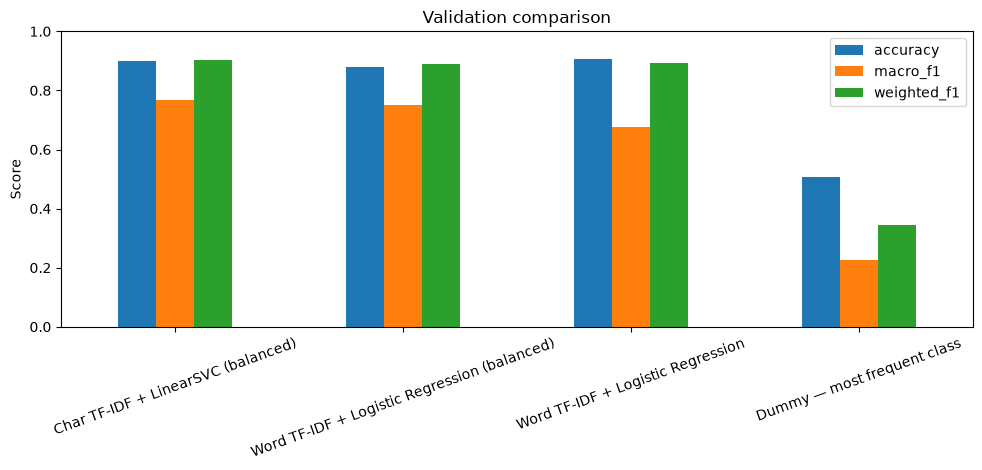

Selected model by validation Macro-F1: Char TF-IDF + LinearSVC (balanced)


In [29]:

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(validation_results.round(4))

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = validation_results.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Validation comparison")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

best_name = validation_results.iloc[0]["model"]
print("Selected model by validation Macro-F1:", best_name)



### Interpretation for the report

Use the table above to answer a concrete question such as:

> **Does class balancing or character-level representation improve sentiment classification compared with the simple word-level baseline?**

This comparison is useful for the assignment's creativity/extension component because it provides a measurable model-to-model comparison rather than only changing visualization styles.


## 7. Final training and test evaluation

In [30]:

# Refit the selected model using train + validation.
# Only now do we evaluate on the held-out test set.
train_valid_df = pd.concat([train_df, valid_df], ignore_index=True)

best_model = clone(model_specs[best_name])
best_model.fit(train_valid_df["text_clean"], train_valid_df["label"])

test_pred = best_model.predict(test_df["text_clean"])
test_metrics = show_metrics(
    f"FINAL TEST — {best_name}",
    test_df["label"],
    test_pred,
)


FINAL TEST — Char TF-IDF + LinearSVC (balanced)
        accuracy: 0.8812
 macro_precision: 0.7463
    macro_recall: 0.7554
        macro_f1: 0.7504
     weighted_f1: 0.8823

              precision    recall  f1-score   support

    negative     0.8847    0.9148    0.8995      1409
     neutral     0.4222    0.4551    0.4380       167
    positive     0.9320    0.8962    0.9138      1590

    accuracy                         0.8812      3166
   macro avg     0.7463    0.7554    0.7504      3166
weighted avg     0.8840    0.8812    0.8823      3166



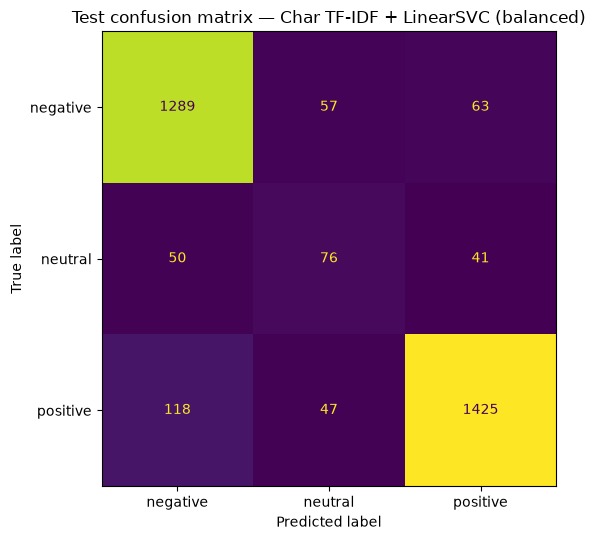

,pred_negative,pred_neutral,pred_positive
true_negative,1289,57,63
true_neutral,50,76,41
true_positive,118,47,1425


In [31]:

# Confusion matrix
cm = confusion_matrix(test_df["label"], test_pred, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title(f"Test confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in LABEL_ORDER],
                    columns=[f"pred_{x}" for x in LABEL_ORDER])
display(cm_df)


## 8. Error analysis

In [32]:

error_df = test_df[["text", "text_clean", "label"]].copy()
error_df["prediction"] = test_pred
error_df = error_df[error_df["label"] != error_df["prediction"]].reset_index(drop=True)

print(f"Misclassified samples: {len(error_df):,} / {len(test_df):,}")
display(error_df[["text", "label", "prediction"]].head(25))


Misclassified samples: 376 / 3,166


,text,label,prediction
0,tính điểm thi đua các nhóm .,positive,neutral
1,trong trường macbook thầy số hai thì không có máy nào số một .,positive,negative
2,bắt đầu buổi học đúng giờ .,positive,negative
3,cách mà cô tiếp cận với sinh viên .,neutral,positive
4,thầy dạy rất nhiệt tình và giảng kỹ bài không cần cải thiện gì cả .,positive,negative
5,giữa lý thuyết từ vựng với trò chơi để dễ tiếp thu .,negative,neutral
6,môn học này giúp chúng em hiểu ra những vấn đề cơ bản .,neutral,positive
7,phần lớn chỉ là lý thuyết và bài tập .,positive,negative
8,như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết .,neutral,negative
9,"ấn tượng nhất doubledot dạy không cần máy chiếu hay laptop , nhưng lượng bài giảng có thể nói là ' khủng ' , nhìn th...",positive,negative


In [33]:

# Which class pairs are most often confused?
error_pairs = (
    error_df.groupby(["label", "prediction"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_pairs)


,label,prediction,count
4,positive,negative,118
1,negative,positive,63
0,negative,neutral,57
2,neutral,negative,50
5,positive,neutral,47
3,neutral,positive,41



When writing the report, inspect several mistakes from the largest confusion pair. Possible reasons may include:

- very short or ambiguous feedback,
- mixed positive and negative opinions in one sentence,
- implicit sentiment,
- spelling/noise,
- label ambiguity.

Do not claim a cause unless the examples shown support it.


## 9. Interpret a word-level linear model

In [34]:

# Inspect discriminative terms from the balanced word-level Logistic Regression model.
interpret_model_name = "Word TF-IDF + Logistic Regression (balanced)"
interpret_model = fitted_models[interpret_model_name]

vectorizer = interpret_model.named_steps["tfidf"]
classifier = interpret_model.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())

top_features = {}
for class_index, class_name in enumerate(classifier.classes_):
    coef = classifier.coef_[class_index]
    top_idx = np.argsort(coef)[-15:][::-1]
    top_features[class_name] = feature_names[top_idx].tolist()

top_features_df = pd.DataFrame({
    label: pd.Series(top_features.get(label, []))
    for label in LABEL_ORDER
})

display(top_features_df)


,negative,neutral,positive
0,nên,không,tốt
1,cần,không có,rất
2,chưa,dung ôn,hay
3,khó,ơn,dễ hiểu
4,hơn,tra thường,tình
5,quá,giống,nhiệt
6,ít,chưa có,vui
7,hơi,rất hiền,nhiệt tình
8,không,đủ số,tận
9,nghỉ,có tương,hiểu



The table above gives an interpretable view of terms that push the linear model toward each sentiment class. In the report, discuss only patterns that are clearly visible in your actual output.


## 10. Example predictions

In [35]:

examples = pd.DataFrame({
    "text": [
        "giảng viên dạy rất dễ hiểu và nhiệt tình",
        "bài giảng quá khó hiểu và thiếu ví dụ",
        "môn học có ba buổi thực hành",
        "thầy dạy tốt nhưng bài tập quá nhiều",
    ]
})

examples["text_clean"] = examples["text"].map(normalize_vi_text)
examples["prediction"] = best_model.predict(examples["text_clean"])

display(examples[["text", "prediction"]])


,text,prediction
0,giảng viên dạy rất dễ hiểu và nhiệt tình,positive
1,bài giảng quá khó hiểu và thiếu ví dụ,negative
2,môn học có ba buổi thực hành,neutral
3,thầy dạy tốt nhưng bài tập quá nhiều,positive


## 11. Reproducible summary

In [36]:

summary = pd.DataFrame([{
    "dataset": "UIT-VSFC",
    "task": "Vietnamese sentiment classification",
    "train_samples": len(train_df),
    "validation_samples": len(valid_df),
    "test_samples": len(test_df),
    "selected_model": best_name,
    "test_accuracy": test_metrics["accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "test_weighted_f1": test_metrics["weighted_f1"],
}])

display(summary.round(4))


,dataset,task,train_samples,validation_samples,test_samples,selected_model,test_accuracy,test_macro_f1,test_weighted_f1
0,UIT-VSFC,Vietnamese sentiment classification,11426,1583,3166,Char TF-IDF + LinearSVC (balanced),0.8812,0.7504,0.8823



## Conclusion template

After running all cells, replace this template with conclusions based on your actual outputs:

- The dataset contains **[N]** Vietnamese feedback samples across three sentiment classes.
- The class distribution is **[balanced / imbalanced]**, so Macro-F1 was used for model selection.
- On the validation set, **[MODEL]** achieved the best Macro-F1 of **[VALUE]**.
- On the held-out test set, the selected model achieved **Accuracy = [VALUE]** and **Macro-F1 = [VALUE]**.
- The largest confusion was **[TRUE CLASS] → [PREDICTED CLASS]**, with **[N]** examples.
- Error analysis suggests **[SUPPORTED OBSERVATION]**.
- A useful extension would be to compare this classical baseline against a Vietnamese pretrained language model such as PhoBERT, provided the group has enough compute and can still keep the notebook reproducible.
